# Klasifikasi Penyakit Jantung dengan Decision Tree dan Random Forest
Tugas Kelompok — P12
Anggota Kelompok:

Muhammad Fadhil Aprilino (24523175)
Pradipta Pramatya Panhar (24523052)
Dataset: Heart Disease Dataset (heart.csv)

Sumber: kaggle

Deskripsi: Dataset ini berisi 1.025 data rekam medis pasien dengan 13 fitur klinis. Target klasifikasi adalah kolom
target:

*   0 = Tidak ada penyakit jantung
*   1 = Terdiagnosis penyakit jantung

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

#1. Memuat dataset

In [ ]:
df = pd.read_csv('heart.csv')

print(f"Ukuran dataset: {df.shape[0]} baris x {df.shape[1]} kolom")
display(df.head(10))

Ukuran dataset: 1025 baris x 14 kolom


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


#2. Preprocessing Data

In [ ]:
print("Missing Values:")
print(df.isnull().sum())

# Cek duplikasi
print(f"\nJumlah baris duplikat: {df.duplicated().sum()}")

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Jumlah baris duplikat: 723


dataset ini tidak punya missing values. ada 723 baris duplikat yang harus dihapus biar model tidak bias karena data yang berulang

In [ ]:
print(f"Ukuran sebelumnya: {df.shape}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Ukuran setelahnya: {df.shape}")

display(df.head())

Ukuran sebelumnya: (1025, 14)
Ukuran setelahnya: (302, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


Menghapus baris duplikat

In [ ]:
kolom_kategori = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

label_encoders = {}
for kolom in kolom_kategori:
    le = LabelEncoder()
    df[kolom] = le.fit_transform(df[kolom])
    label_encoders[kolom] = le

# Encode target
le_target = LabelEncoder()
df['target_encoded'] = le_target.fit_transform(df['target'])

display(df.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,target_encoded
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,0


fitur yang disimpan sebagai numerik tapi bersifat kategorikal sudah di encode ulang biar konsisten. meliputi : sex,cp,fbs,restecg,exang,slope,ca,dan thal yang merupakan kategorikal walaupun datanya angka

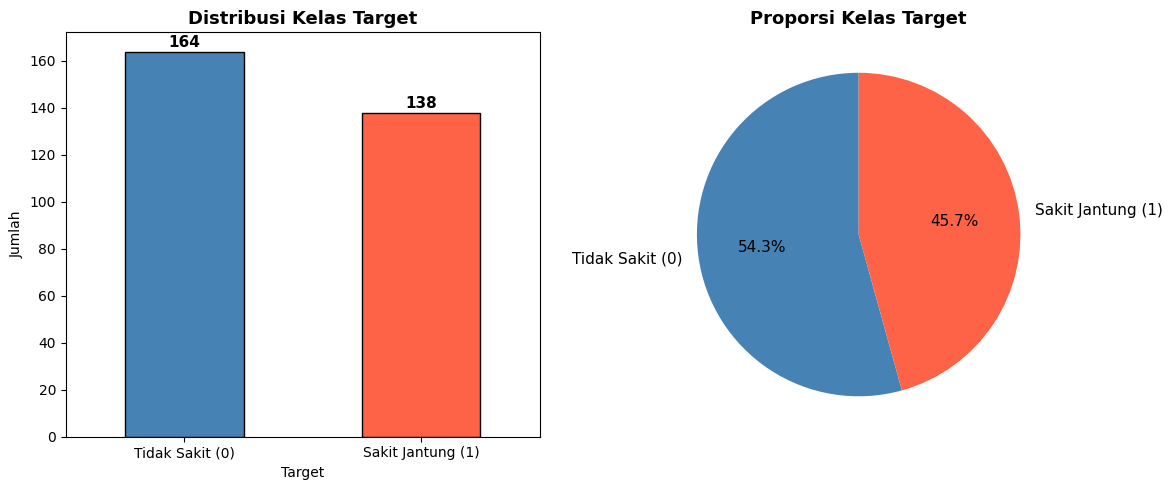

In [ ]:
jumlah_target = df['target'].value_counts()
label_target = ['Tidak Sakit (0)', 'Sakit Jantung (1)']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
jumlah_target.plot(kind='bar', ax=ax1, color=['steelblue', 'tomato'],
                   edgecolor='black', rot=0)
ax1.set_title('Distribusi Kelas Target', fontsize=13, fontweight='bold')
ax1.set_xlabel('Target')
ax1.set_ylabel('Jumlah')
ax1.set_xticklabels(label_target)
for i, v in enumerate(jumlah_target):
    ax1.text(i, v + 2, str(v), ha='center', fontweight='bold', fontsize=11)

# Pie chart
ax2.pie(jumlah_target, labels=label_target, autopct='%1.1f%%',
        colors=['steelblue', 'tomato'], startangle=90, textprops={'fontsize': 11})
ax2.set_title('Proporsi Kelas Target', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

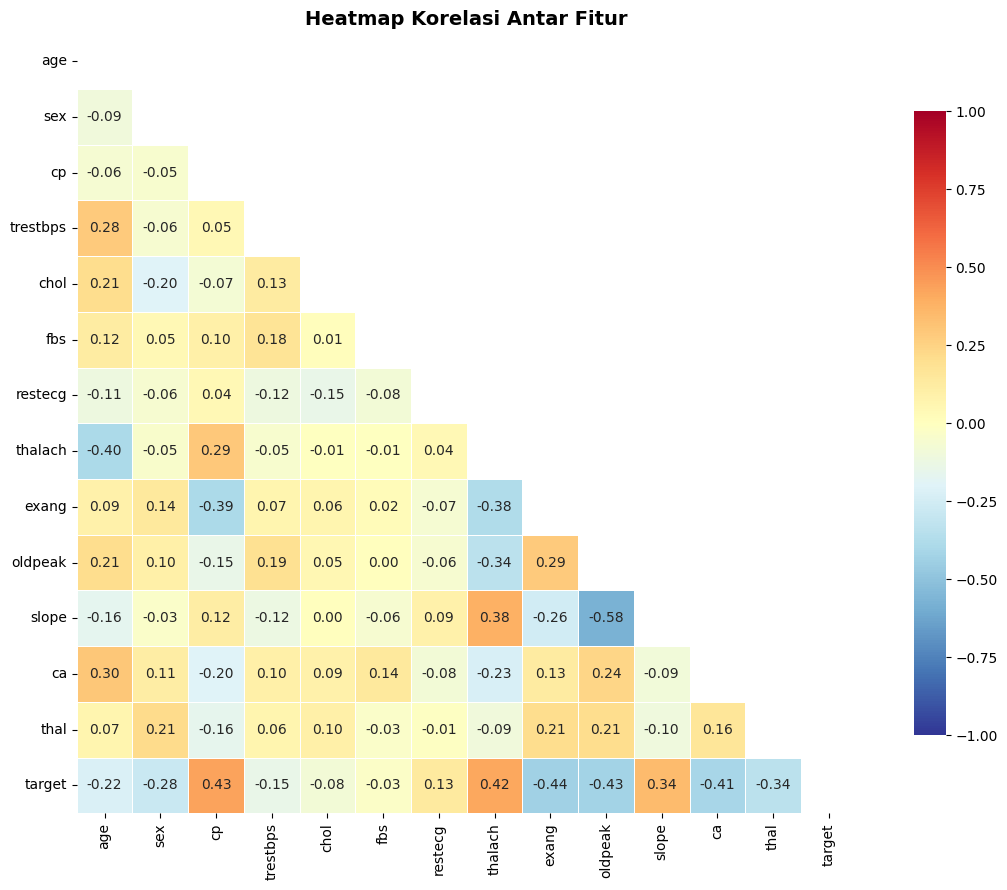

In [ ]:
plt.figure(figsize=(12, 9))
korelasi = df.drop(columns=['target_encoded']).corr()

mask = np.triu(np.ones_like(korelasi, dtype=bool))
sns.heatmap(korelasi, annot=True, fmt='.2f', cmap='RdYlBu_r',
            mask=mask, linewidths=0.5, linecolor='white',
            vmin=-1, vmax=1, center=0, square=True, cbar_kws={"shrink": 0.8})

plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#3. Membagi Data Training dengan Data Testing

In [ ]:
# Memisahkan fitur dengan label
X = df.drop(columns=['target', 'target_encoded'])
y = df['target_encoded']

# Split data
X_Training, X_Testing, y_Training, y_Testing = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Data Training : {X_Training.shape[0]} sampel")
print(f"Data Testing   : {X_Testing.shape[0]} sampel")
print(f"\nDistribusi kelas di data Training:\n{y_Training.value_counts().to_string()}")
print(f"\nDistribusi kelas di data Testing:\n{y_Testing.value_counts().to_string()}")

Data Training : 241 sampel
Data Testing   : 61 sampel

Distribusi kelas di data Training:
target_encoded
1    131
0    110

Distribusi kelas di data Testing:
target_encoded
1    33
0    28


#4. Model Decision Tree

In [ ]:
# Membuat Decision Tree
dt_classifier = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_classifier.fit(X_Training, y_Training)

print(f"Kedalaman pohon   : {dt_classifier.get_depth()}")
print(f"Jumlah daun (leaf): {dt_classifier.get_n_leaves()}")

Kedalaman pohon   : 5
Jumlah daun (leaf): 22


Melatih model menggunakan DecisionTreeClassifier dari sklearn dengan max_depth=5 supaya tidak overfitting

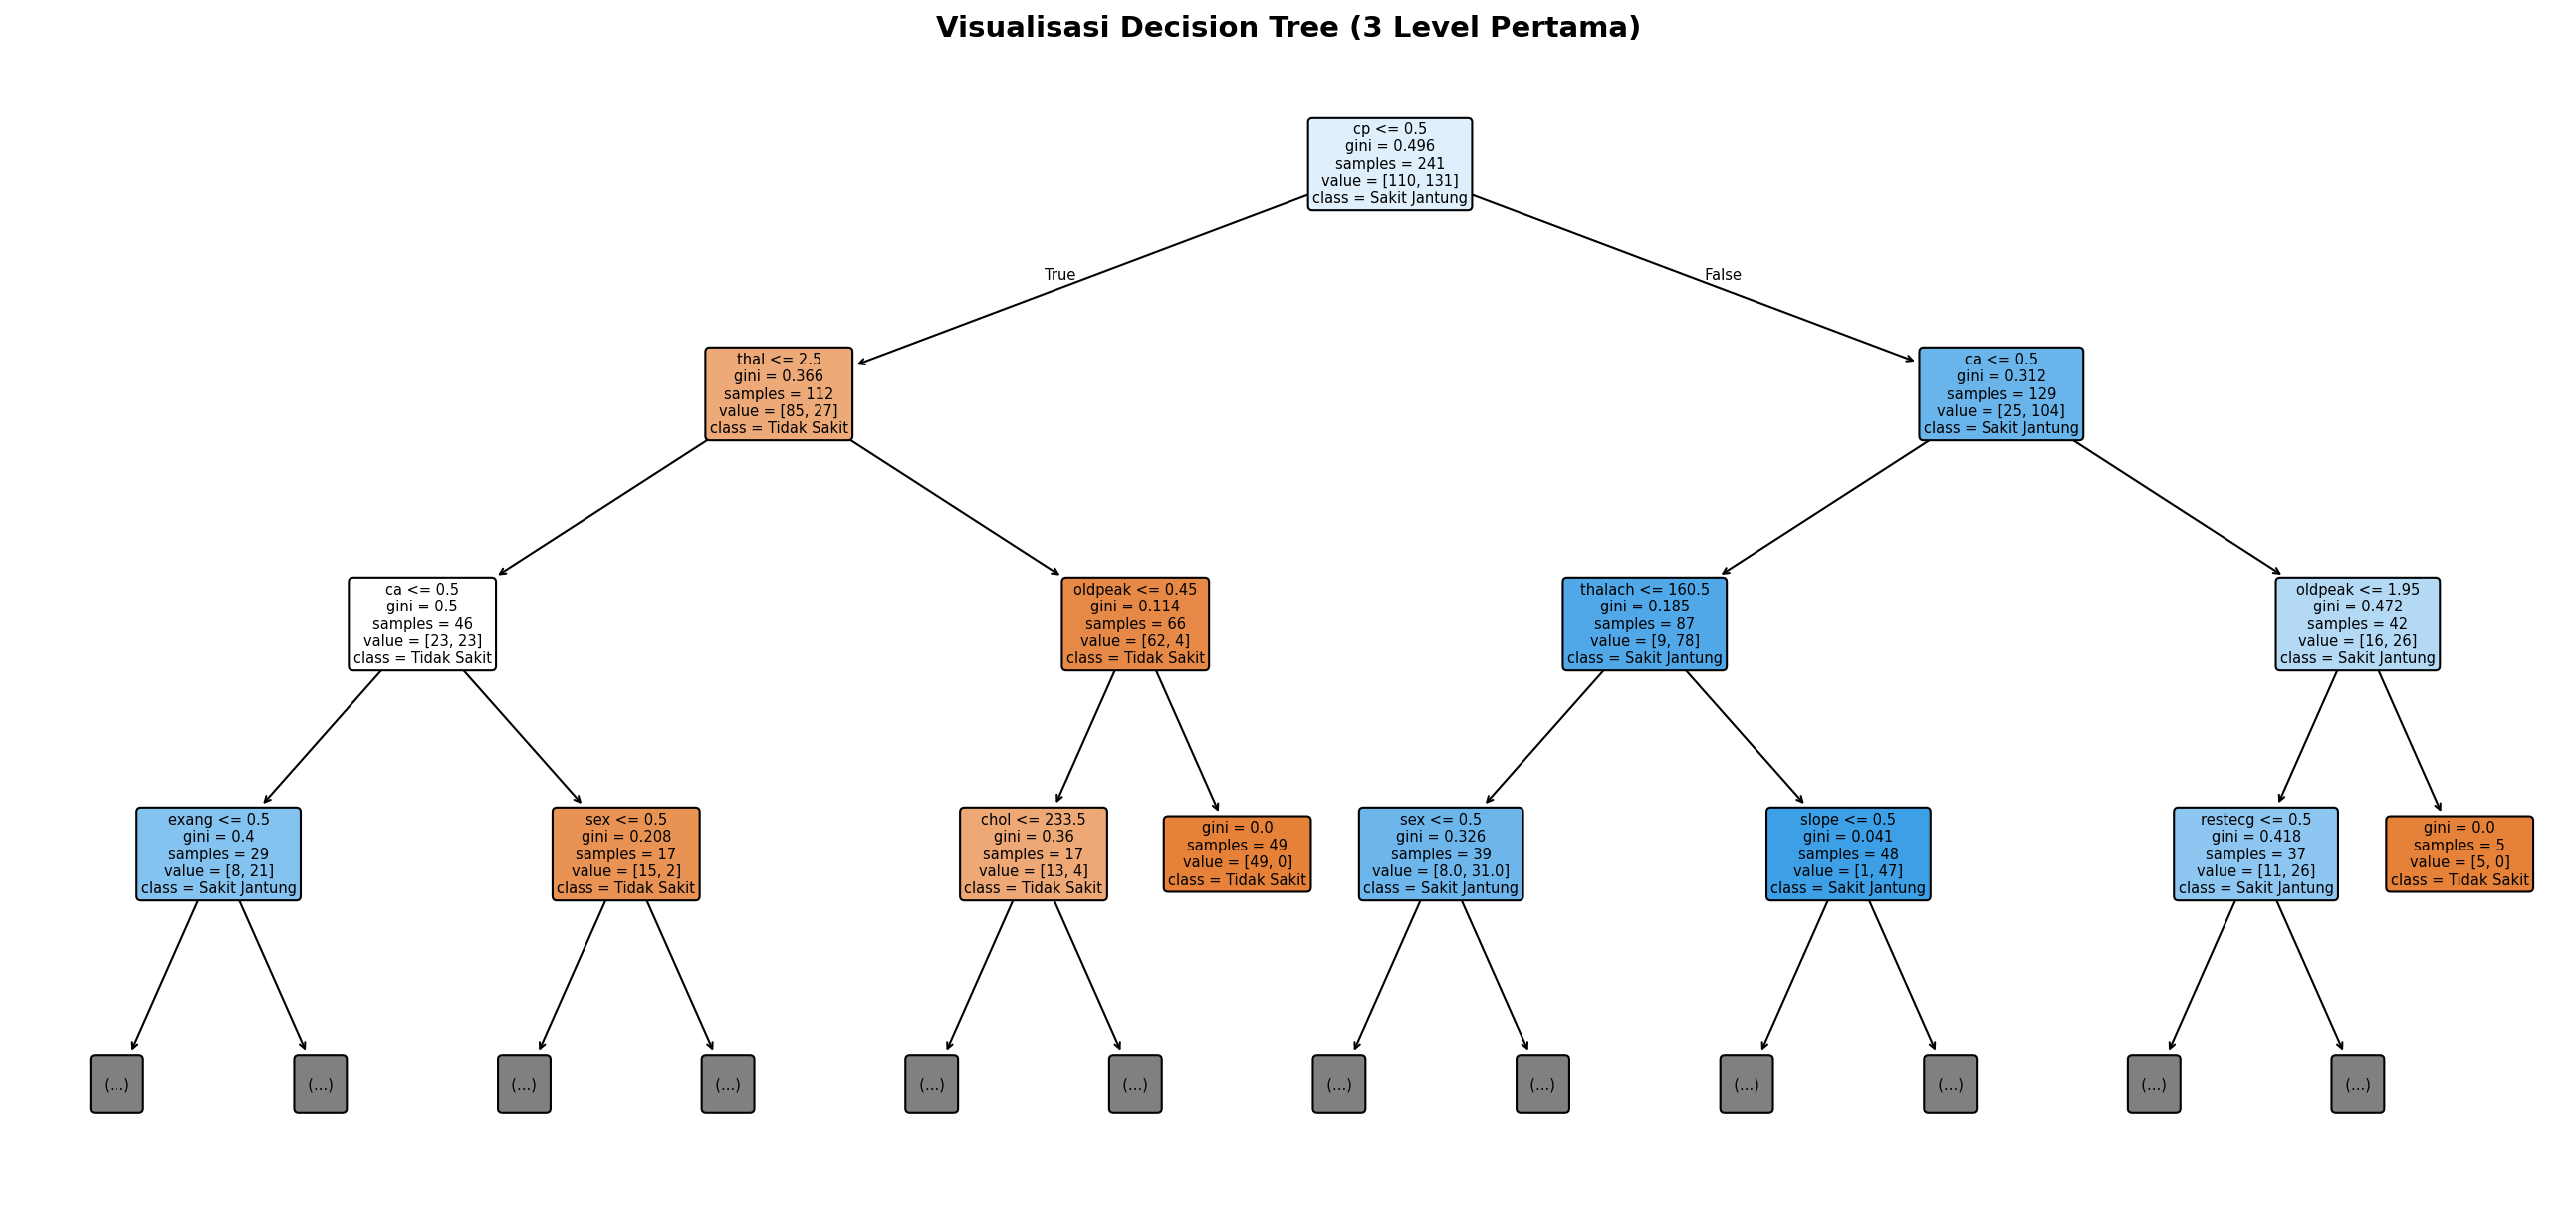

 Menampilkan 3 level pertama suoaya terbaca jelas.


In [ ]:
# Visualisasi pohon
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(22, 10), dpi=150)

plot_tree(dt_classifier,
          feature_names=X.columns,
          class_names=['Tidak Sakit', 'Sakit Jantung'],
          filled=True,
          rounded=True,
          fontsize=7,
          max_depth=3)

plt.title('Visualisasi Decision Tree (3 Level Pertama)', fontsize=14, fontweight='bold')
plt.show()

print(" Menampilkan 3 level pertama suoaya terbaca jelas.")

In [ ]:
# Prediksi
prediksi_dt_Training = dt_classifier.predict(X_Training)
prediksi_dt_Testing   = dt_classifier.predict(X_Testing)

# Akurasi
akurasi_dt_Training = accuracy_score(y_Training, prediksi_dt_Training)
akurasi_dt_Testing   = accuracy_score(y_Testing, prediksi_dt_Testing)

print("EVALUASI DECISION TREE:")
print(f"Akurasi Data Training : {akurasi_dt_Training*100:.2f}%")
print(f"Akurasi Data Testing   : {akurasi_dt_Testing*100:.2f}%")
print(f"Selisih (gap)      : {(akurasi_dt_Training - akurasi_dt_Testing)*100:.2f}%")

print("\nClassification Report (Data Testing):")
print(classification_report(y_Testing, prediksi_dt_Testing,
      target_names=['Tidak Sakit', 'Sakit Jantung']))

EVALUASI DECISION TREE:
Akurasi Data Training : 94.19%
Akurasi Data Testing   : 77.05%
Selisih (gap)      : 17.14%

Classification Report (Data Testing):
               precision    recall  f1-score   support

  Tidak Sakit       0.73      0.79      0.76        28
Sakit Jantung       0.81      0.76      0.78        33

     accuracy                           0.77        61
    macro avg       0.77      0.77      0.77        61
 weighted avg       0.77      0.77      0.77        61



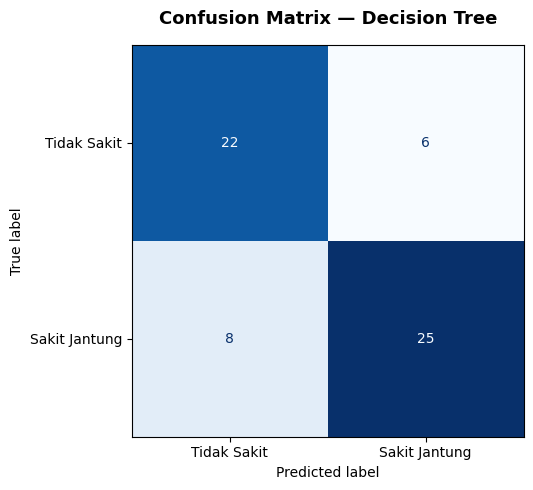

True Negative  (prediksi tidak sakit, benar)        : 22
False Positive (prediksi sakit, padahal tidak sakit) : 6
False Negative (prediksi tidak sakit, padahal sakit) : 8
True Positive  (prediksi sakit, benar)              : 25


In [ ]:
# Confusion Matrix decision tree
fig, ax = plt.subplots(figsize=(10, 5))

cm_dt = confusion_matrix(y_Testing, prediksi_dt_Testing)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt,
                                  display_labels=['Tidak Sakit', 'Sakit Jantung'])
disp_dt.plot(ax=ax, cmap='Blues', colorbar=False)

ax.set_title('Confusion Matrix — Decision Tree', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_dt.ravel()
print(f"True Negative  (prediksi tidak sakit, benar)        : {tn}")
print(f"False Positive (prediksi sakit, padahal tidak sakit) : {fp}")
print(f"False Negative (prediksi tidak sakit, padahal sakit) : {fn}")
print(f"True Positive  (prediksi sakit, benar)              : {tp}")

In [ ]:
# Prediksi data baru menggunakan decision tree
# Contoh: 2 pasien baru dengan kondisi berbeda
data_baru = {
    'age':      [55, 45],
    'sex':      [1, 0],
    'cp':       [0, 2],
    'trestbps': [140, 120],
    'chol':     [250, 180],
    'fbs':      [0, 0],
    'restecg':  [0, 1],
    'thalach':  [150, 170],
    'exang':    [1, 0],
    'oldpeak':  [2.3, 0.5],
    'slope':    [0, 2],
    'ca':       [1, 0],
    'thal':     [3, 2]
}

df_baru = pd.DataFrame(data_baru)

# Encode fitur kategorikal data baru
for kolom in kolom_kategori:
    if kolom in label_encoders:
        df_baru[kolom] = label_encoders[kolom].transform(df_baru[kolom])

prediksi_baru = dt_classifier.predict(df_baru)
label_prediksi = le_target.inverse_transform(prediksi_baru)

print("Prediksi untuk data pasien baru:")
for i, label in enumerate(label_prediksi):
    print(f"  Pasien {i+1}: {label} ({'Sakit Jantung' if label == 1 else 'Tidak Sakit'})")

Prediksi untuk data pasien baru:
  Pasien 1: 0 (Tidak Sakit)
  Pasien 2: 1 (Sakit Jantung)


#5. Model Random Forest

Pengaruh n_estimators pada akurasi

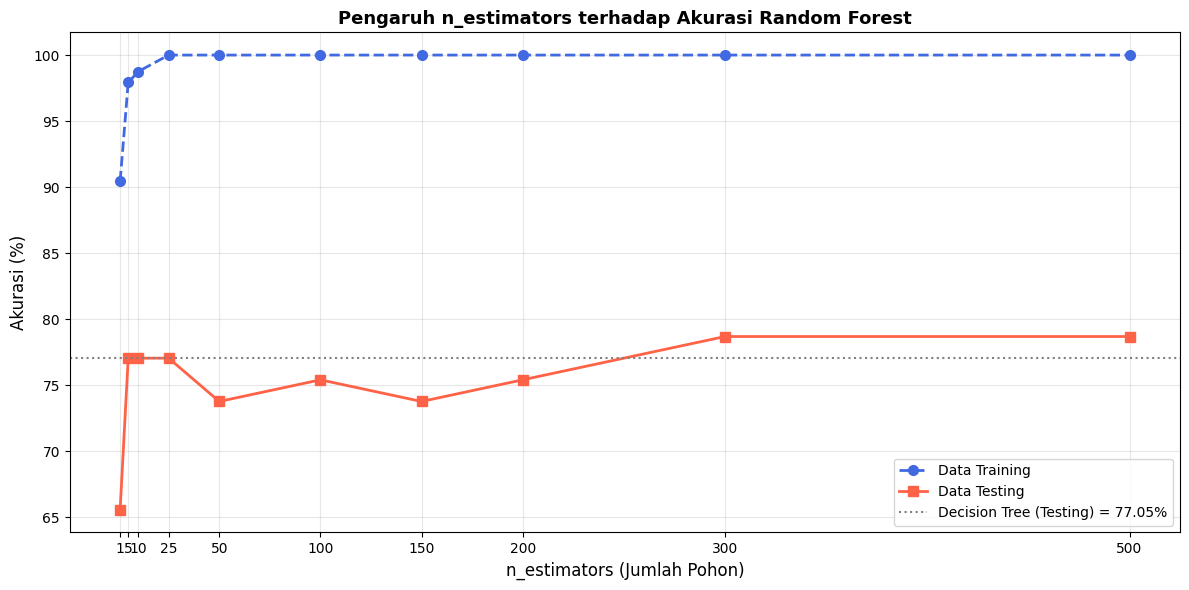

   n_estimators | Akurasi Training | Akurasi Testing
-----------------------------------------------
              1 |         90.46% |       65.57%
              5 |         97.93% |       77.05%
             10 |         98.76% |       77.05%
             25 |        100.00% |       77.05%
             50 |        100.00% |       73.77%
            100 |        100.00% |       75.41%
            150 |        100.00% |       73.77%
            200 |        100.00% |       75.41%
            300 |        100.00% |       78.69%
            500 |        100.00% |       78.69%


In [ ]:
daftar_estimator = [1, 5, 10, 25, 50, 100, 150, 200, 300, 500]
akurasi_Training_rf = []
akurasi_Testing_rf   = []

for n in daftar_estimator:
    rf_temp = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf_temp.fit(X_Training, y_Training)
    akurasi_Training_rf.append(accuracy_score(y_Training, rf_temp.predict(X_Training)))
    akurasi_Testing_rf.append(accuracy_score(y_Testing, rf_temp.predict(X_Testing)))

# Plot
plt.figure(figsize=(12, 6))
plt.plot(daftar_estimator, [a*100 for a in akurasi_Training_rf],
         'o--', color='royalblue', linewidth=2, markersize=7, label='Data Training')
plt.plot(daftar_estimator, [a*100 for a in akurasi_Testing_rf],
         's-', color='tomato', linewidth=2, markersize=7, label='Data Testing')
plt.axhline(y=akurasi_dt_Testing*100, color='gray', linestyle=':', linewidth=1.5,
            label=f'Decision Tree (Testing) = {akurasi_dt_Testing*100:.2f}%')

plt.xlabel('n_estimators (Jumlah Pohon)', fontsize=12)
plt.ylabel('Akurasi (%)', fontsize=12)
plt.title('Pengaruh n_estimators terhadap Akurasi Random Forest', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.xticks(daftar_estimator)
plt.tight_layout()
plt.show()

# Tabel
print(f"{'n_estimators':>15} | {'Akurasi Training':>14} | {'Akurasi Testing':>12}")
print("-" * 47)
for n, al, au in zip(daftar_estimator, akurasi_Training_rf, akurasi_Testing_rf):
    print(f"{n:>15} | {al*100:>13.2f}% | {au*100:>11.2f}%")

Grafik ini menampilkan akurasi data uji yang mulai stabil pada n_estimators = 100. untuk penambahan pohon setelah ini tidak memberikan peningkatan yang signifikan yang dimana hanya menambah waktu untuk komputasi

In [ ]:
# membuat model Random Forest
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_classifier.fit(X_Training, y_Training)

print(f"Jumlah pohon : {rf_classifier.n_estimators}")
print(f"Jumlah fitur : {rf_classifier.n_features_in_}")

Jumlah pohon : 100
Jumlah fitur : 13


In [ ]:
# Evaluasi model random forest
prediksi_rf_Training = rf_classifier.predict(X_Training)
prediksi_rf_Testing   = rf_classifier.predict(X_Testing)

akurasi_rf_Training = accuracy_score(y_Training, prediksi_rf_Training)
akurasi_rf_Testing   = accuracy_score(y_Testing, prediksi_rf_Testing)

print("EVALUASI RANDOM FOREST:")
print(f"Akurasi Data Training : {akurasi_rf_Training*100:.2f}%")
print(f"Akurasi Data Testing  : {akurasi_rf_Testing*100:.2f}%")
print(f"Selisih (gap)      : {(akurasi_rf_Training - akurasi_rf_Testing)*100:.2f}%")

print("\nClassification Report (Data Testing):")
print(classification_report(y_Testing, prediksi_rf_Testing,
      target_names=['Tidak Sakit', 'Sakit Jantung']))

EVALUASI RANDOM FOREST:
Akurasi Data Training : 100.00%
Akurasi Data Testing  : 75.41%
Selisih (gap)      : 24.59%

Classification Report (Data Testing):
               precision    recall  f1-score   support

  Tidak Sakit       0.74      0.71      0.73        28
Sakit Jantung       0.76      0.79      0.78        33

     accuracy                           0.75        61
    macro avg       0.75      0.75      0.75        61
 weighted avg       0.75      0.75      0.75        61



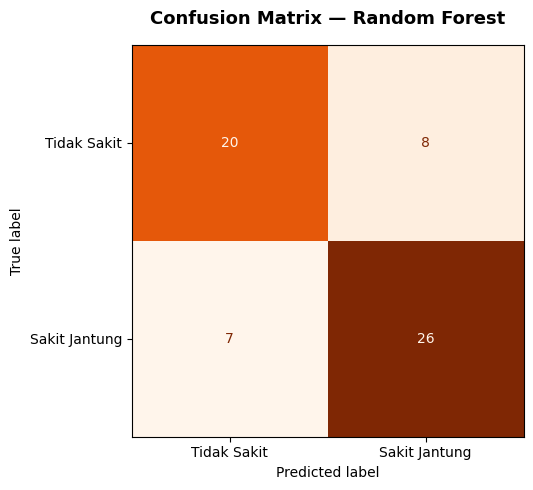

True Negative  (prediksi tidak sakit, benar)        : 20
False Positive (prediksi sakit, padahal tidak sakit) : 8
False Negative (prediksi tidak sakit, padahal sakit) : 7
True Positive  (prediksi sakit, benar)              : 26


In [ ]:
# Confusion matrix random forest
fig, ax = plt.subplots(figsize=(10, 5))

cm_rf = confusion_matrix(y_Testing, prediksi_rf_Testing)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                                  display_labels=['Tidak Sakit', 'Sakit Jantung'])
disp_rf.plot(ax=ax, cmap='Oranges', colorbar=False)

ax.set_title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()
print(f"True Negative  (prediksi tidak sakit, benar)        : {tn_rf}")
print(f"False Positive (prediksi sakit, padahal tidak sakit) : {fp_rf}")
print(f"False Negative (prediksi tidak sakit, padahal sakit) : {fn_rf}")
print(f"True Positive  (prediksi sakit, benar)              : {tp_rf}")

In [ ]:
# Prediksi data baru menggunakan Random Forest
prediksi_rf_baru = rf_classifier.predict(df_baru)
label_rf_baru = le_target.inverse_transform(prediksi_rf_baru)

print("Prediksi Random Forest untuk data pasien baru:")
for i, label in enumerate(label_rf_baru):
    print(f"  Pasien {i+1}: {label} ({'Sakit Jantung' if label == 1 else 'Tidak Sakit'})")

Prediksi Random Forest untuk data pasien baru:
  Pasien 1: 0 (Tidak Sakit)
  Pasien 2: 1 (Sakit Jantung)


#6. Membandingkan decision tree dengan random forest

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Ringkasan tabel
print(f"{'Metrik':<25} | {'Decision Tree':>13} | {'Random Forest':>13}")
print(f"{'Akurasi Data Training':<25} | {akurasi_dt_Training*100:>12.2f}% | {akurasi_rf_Training*100:>12.2f}%")
print(f"{'Akurasi Data Testing':<25} | {akurasi_dt_Testing*100:>12.2f}% | {akurasi_rf_Testing*100:>12.2f}%")
print(f"{'Gap (Training - Testing)':<25} | {(akurasi_dt_Training-akurasi_dt_Testing)*100:>12.2f}% | {(akurasi_rf_Training-akurasi_rf_Testing)*100:>12.2f}%")


for nama, y_pred in [("Decision Tree", prediksi_dt_Testing), ("Random Forest", prediksi_rf_Testing)]:
    prec = precision_score(y_Testing, y_pred, average='weighted')
    rec  = recall_score(y_Testing, y_pred, average='weighted')
    f1   = f1_score(y_Testing, y_pred, average='weighted')
    print(f"\n{nama}:")
    print(f"  Precision : {prec*100:.2f}%")
    print(f"  Recall    : {rec*100:.2f}%")
    print(f"  F1-Score  : {f1*100:.2f}%")

Metrik                    | Decision Tree | Random Forest
Akurasi Data Training     |        94.19% |       100.00%
Akurasi Data Testing      |        77.05% |        75.41%
Gap (Training - Testing)  |        17.14% |        24.59%

Decision Tree:
  Precision : 77.29%
  Recall    : 77.05%
  F1-Score  : 77.09%

Random Forest:
  Precision : 75.37%
  Recall    : 75.41%
  F1-Score  : 75.37%


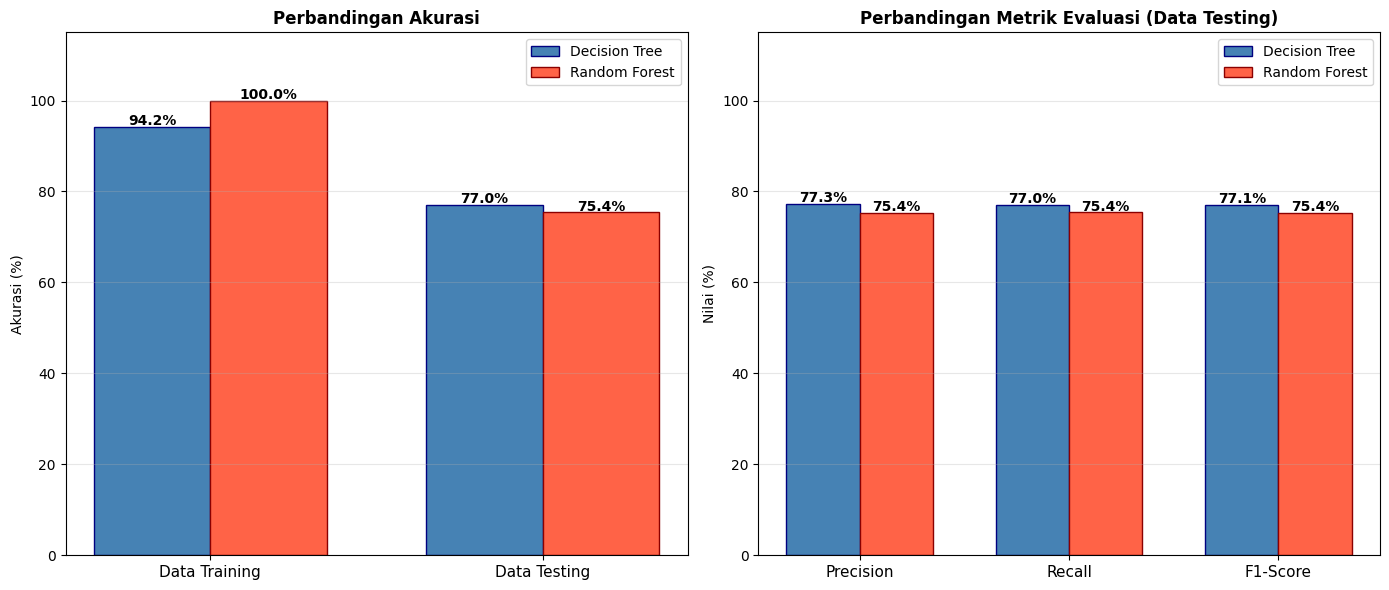

In [ ]:
# Visualisasi perbandingan
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
lebar = 0.35

# Akurasi
kategori = ['Data Training', 'Data Testing']
nilai_dt = [akurasi_dt_Training*100, akurasi_dt_Testing*100]
nilai_rf = [akurasi_rf_Training*100, akurasi_rf_Testing*100]
x = np.arange(len(kategori))

b1 = axes[0].bar(x - lebar/2, nilai_dt, lebar, label='Decision Tree',
                  color='steelblue', edgecolor='navy')
b2 = axes[0].bar(x + lebar/2, nilai_rf, lebar, label='Random Forest',
                  color='tomato', edgecolor='darkred')
for bar in list(b1) + list(b2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(kategori, fontsize=11)
axes[0].set_ylabel('Akurasi (%)')
axes[0].set_title('Perbandingan Akurasi', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 115)
axes[0].grid(axis='y', alpha=0.3)

# Metrik
metrik_nama = ['Precision', 'Recall', 'F1-Score']
metrik_dt = [precision_score(y_Testing, prediksi_dt_Testing, average='weighted')*100,
             recall_score(y_Testing, prediksi_dt_Testing, average='weighted')*100,
             f1_score(y_Testing, prediksi_dt_Testing, average='weighted')*100]
metrik_rf = [precision_score(y_Testing, prediksi_rf_Testing, average='weighted')*100,
             recall_score(y_Testing, prediksi_rf_Testing, average='weighted')*100,
             f1_score(y_Testing, prediksi_rf_Testing, average='weighted')*100]
x2 = np.arange(len(metrik_nama))

b3 = axes[1].bar(x2 - lebar/2, metrik_dt, lebar, label='Decision Tree',
                  color='steelblue', edgecolor='navy')
b4 = axes[1].bar(x2 + lebar/2, metrik_rf, lebar, label='Random Forest',
                  color='tomato', edgecolor='darkred')
for bar in list(b3) + list(b4):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(metrik_nama, fontsize=11)
axes[1].set_ylabel('Nilai (%)')
axes[1].set_title('Perbandingan Metrik Evaluasi (Data Testing)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].set_ylim(0, 115)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#7. Analisis

##7.1 Algoritma mana yang memberikan performa terbaik? Jelaskan.

Jawaban :

Berdasarkan hasil evaluasi pada data testing:

*   **Decision Tree:** Akurasi = 77.05%, Precision = 77.29%, Recall = 77.05%, F1-Score = 77.09%
*   **Random Forest:** Akurasi = 75.41%, Precision = 75.37%, Recall = 75.41%, F1-Score = 75.37%

Pada kasus ini, **Decision Tree** memberikan performa yang sedikit lebih baik dibandingkan Random Forest pada data testing, dengan akurasi dan metrik lainnya yang sedikit lebih tinggi. Meskipun Random Forest seringkali lebih unggul karena kemampuannya mengatasi overfitting, pada dataset ini, Decision Tree (dengan `max_depth=5` yang membantu mengontrol overfitting) menunjukkan hasil yang kompetitif.

##7.2 Apa kelebihan dan kekurangan Decision Tree dibanding Random Forest?

Jawaban :

**Kelebihan dan Kekurangan Decision Tree:**
*   **Kelebihan:**
    *   **Mudah Diinterpretasi:** Struktur pohon yang jelas membuatnya mudah dipahami bagaimana keputusan dibuat.
    *   **Tidak Perlu Normalisasi Data:** Tidak terpengaruh oleh skala fitur, sehingga tidak memerlukan normalisasi atau standarisasi.
    *   **Cepat:** Proses pelatihan dan prediksi cenderung cepat untuk dataset yang tidak terlalu besar.
*   **Kekurangan:**
    *   **Rentan Overfitting:** Cenderung membangun pohon yang terlalu kompleks yang cocok dengan data training tetapi buruk dalam menggeneralisasi data baru.
    *   **Tidak Stabil:** Perubahan kecil pada data training dapat menghasilkan pohon yang sangat berbeda.
    *   **Bias:** Bisa menghasilkan pohon yang bias jika ada kelas yang tidak seimbang.

**Kelebihan dan Kekurangan Random Forest:**
*   **Kelebihan:**
    *   **Mengatasi Overfitting:** Dengan menggabungkan banyak pohon keputusan, Random Forest secara signifikan mengurangi risiko overfitting.
    *   **Akurasi Tinggi:** Umumnya memberikan akurasi yang lebih tinggi dibandingkan Decision Tree tunggal.
    *   **Lebih Stabil:** Kurang sensitif terhadap perubahan kecil pada data training karena sifat ensemble-nya.
    *   **Penanganan Data Berdimensi Tinggi:** Dapat menangani dataset dengan banyak fitur.
    *   **Estimasi Pentingnya Fitur:** Dapat memberikan indikasi fitur mana yang paling penting dalam klasifikasi.
*   **Kekurangan:**
    *   **Kurang Terinterpretasi (Black Box):** Karena terdiri dari banyak pohon, Random Forest lebih sulit diinterpretasikan dibandingkan Decision Tree tunggal.
    *   **Membutuhkan Lebih Banyak Sumber Daya Komputasi:** Proses pelatihan lebih lama dan membutuhkan memori lebih besar karena membangun banyak pohon.

##7.3 Apakah ada indikasi overfitting pada Decision Tree? Jelaskan.

Jawaban :

Ya, ada indikasi overfitting pada Decision Tree yang dilatih. Hal ini terlihat dari perbedaan yang cukup signifikan antara akurasi pada data training dan data testing:

*   **Akurasi Data Training:** 94.19%
*   **Akurasi Data Testing:** 77.05%
*   **Selisih (gap):** 17.14%

Akurasi yang sangat tinggi pada data training (94.19%) menunjukkan bahwa model Decision Tree telah 'menghafal' data training dengan sangat baik. Namun, ketika diuji pada data testing yang belum pernah dilihat sebelumnya, akurasinya menurun menjadi 77.05%. Selisih sebesar 17.14% ini adalah indikator kuat bahwa model Decision Tree mengalami overfitting, yaitu model terlalu kompleks dan kurang mampu menggeneralisasi pola dari data training ke data baru.

##7.4 Bagaimana fitur-fitur memengaruhi hasil klasifikasi?

Jawaban :

In [ ]:
importances = rf_classifier.feature_importances_
feature_names = X.columns

forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots(figsize=(10, 7))
forest_importances.sort_values(ascending=False).plot.bar(ax=ax, color='lightcoral', edgecolor='darkred')
ax.set_title("Feature Importances dari Random Forest")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

Jawaban :

Berdasarkan feature importance dari model Random Forest, dapat dilihat bahwa beberapa fitur memiliki pengaruh yang lebih signifikan terhadap hasil klasifikasi penyakit jantung. Fitur dengan nilai importance yang tinggi menunjukkan bahwa fitur tersebut sangat membantu model dalam membuat keputusan klasifikasi.

Misalnya, jika `cp` (jenis nyeri dada) dan `thalach` (detak jantung maksimum) memiliki nilai importance tertinggi, ini berarti perubahan pada nilai-nilai fitur tersebut memiliki dampak besar pada probabilitas seseorang terdiagnosis penyakit jantung. Analisis lebih lanjut terhadap fitur-fitur ini dapat memberikan wawasan medis yang berharga.

(Catatan: Hasil spesifik akan terlihat setelah kode di atas dijalankan dan plot feature importance ditampilkan).

#8. Jawaban Pertanyaan P12

##8.1 Apa perbedaan mendasar antara Decision Tree dan Random Forest?

Jawaban :

Perbedaan mendasar antara Decision Tree dan Random Forest terletak pada kompleksitas dan cara pengambilan keputusannya:

*   **Decision Tree:** Adalah algoritma pembelajaran mesin tunggal yang bekerja dengan membagi data secara rekursif menjadi subkelompok-subkelompok berdasarkan fitur-fitur tertentu. Ini menghasilkan struktur seperti pohon, di mana setiap node internal merepresentasikan pengujian pada atribut, setiap cabang merepresentasikan hasil pengujian, dan setiap node daun (leaf node) merepresentasikan label kelas atau nilai keputusan. Decision Tree cenderung mudah diinterpretasikan.

*   **Random Forest:** Adalah algoritma ensemble yang membangun banyak Decision Tree (forest) selama pelatihan. Setiap pohon dalam Random Forest dibangun dari subset data pelatihan yang di-bootstrap (pengambilan sampel dengan pengembalian) dan subset fitur yang dipilih secara acak. Untuk klasifikasi, output Random Forest adalah kelas yang paling sering dipilih oleh masing-masing pohon (voting mayoritas). Untuk regresi, itu adalah rata-rata prediksi dari masing-masing pohon. Random Forest dirancang untuk mengatasi masalah overfitting dari Decision Tree tunggal dan meningkatkan akurasi.

##8.2 Mengapa Decision Tree rentan overfitting dan bagaimana Random Forest mengatasinya?


Jawaban :

*   **Mengapa Decision Tree rentan overfitting?**
    Decision Tree tunggal rentan overfitting karena cenderung membuat pohon yang sangat dalam dan kompleks. Ketika tidak ada batasan (`max_depth` atau `min_samples_leaf`), Decision Tree akan terus membagi data hingga setiap node daun murni (hanya berisi satu kelas) atau mencapai satu sampel per daun. Ini berarti pohon tersebut 'menghafal' noise dan anomali dalam data pelatihan, bukan mempelajari pola umum. Akibatnya, ia berkinerja sangat baik pada data pelatihan tetapi sangat buruk pada data baru yang belum pernah dilihat.

*   **Bagaimana Random Forest mengatasinya?**
    Random Forest mengatasi overfitting melalui dua mekanisme utama:
    1.  **Bagging (Bootstrap Aggregating):** Random Forest membangun setiap pohon dari sampel data pelatihan yang berbeda, yang diambil secara acak dengan pengembalian (bootstrap). Ini memastikan bahwa setiap pohon melihat sedikit perbedaan dalam data, mengurangi varians model.
    2.  **Random Feature Subset Selection:** Pada setiap split node dalam Decision Tree, Random Forest hanya mempertimbangkan subset fitur yang dipilih secara acak, bukan semua fitur yang tersedia. Ini mengurangi korelasi antar pohon dan membuat setiap pohon lebih independen, sehingga meningkatkan keandalan prediksi ensemble.

##8.3 Apa fungsi bagging dan pemilihan subset fitur acak pada Random Forest?

Jawaban :

*   **Fungsi Bagging (Bootstrap Aggregating):**
    Bagging adalah teknik ensemble yang melibatkan pembuatan beberapa versi model pelatihan yang berbeda dari data pelatihan yang sama. Dalam konteks Random Forest, 'bootstrap' berarti pengambilan sampel dengan pengembalian dari data pelatihan asli untuk membuat beberapa dataset pelatihan yang baru (disebut bootstrap samples). Setiap Decision Tree kemudian dilatih secara independen pada salah satu dari bootstrap samples ini. Fungsi utama bagging adalah mengurangi varians (overfitting) dari model individual dengan menggabungkan prediksi dari beberapa model yang dilatih pada subset data yang sedikit berbeda.

*   **Pemilihan Subset Fitur Acak:**
    Pada setiap tahap pembentukan Decision Tree di dalam Random Forest (yaitu, pada setiap split node), algoritma tidak mempertimbangkan semua fitur yang tersedia untuk menemukan split terbaik. Sebaliknya, ia hanya mempertimbangkan subset fitur yang dipilih secara acak dari total fitur. Fungsi dari pemilihan subset fitur acak ini adalah:
    1.  **Mengurangi Korelasi antar Pohon:** Memastikan bahwa pohon-pohon dalam forest lebih beragam dan tidak terlalu berkorelasi. Jika semua pohon selalu memilih fitur yang sama sebagai pemisah terbaik, mereka akan menghasilkan prediksi yang sangat mirip, dan manfaat dari ensemble akan berkurang.
    2.  **Meningkatkan Robustness:** Membuat model lebih tangguh terhadap noise atau outlier pada fitur tertentu karena tidak semua pohon akan selalu bergantung pada fitur yang sama.
    3.  **Mempercepat Komputasi:** Mengurangi jumlah fitur yang harus dievaluasi pada setiap split, yang dapat mempercepat proses pelatihan untuk dataset dengan dimensi tinggi.

##8.4 Kapan Decision Tree lebih cocok digunakan dibanding Random Forest?

Jawaban :

Decision Tree lebih cocok digunakan dibanding Random Forest dalam beberapa skenario:

1.  **Interpretasi dan Penjelasan Model yang Tinggi:** Jika interpretasi model sangat penting dan Anda perlu menjelaskan bagaimana keputusan dibuat secara transparan (misalnya, dalam aplikasi medis atau keuangan yang diatur ketat). Decision Tree memberikan visualisasi yang jelas dan jalur keputusan yang mudah dipahami.
2.  **Dataset Kecil atau Sederhana:** Untuk dataset yang relatif kecil atau yang memiliki hubungan fitur-target yang linear/sederhana, Decision Tree tunggal mungkin sudah cukup akurat dan tidak memerlukan kompleksitas komputasi tambahan dari Random Forest.
3.  **Keterbatasan Sumber Daya Komputasi:** Jika Anda memiliki keterbatasan memori atau waktu komputasi, melatih satu Decision Tree akan jauh lebih cepat dan membutuhkan lebih sedikit sumber daya dibandingkan Random Forest yang melatih banyak pohon.
4.  **Sebagai Baseline Awal:** Decision Tree dapat menjadi model baseline yang cepat untuk dicoba dan dievaluasi sebelum beralih ke model ensemble yang lebih kompleks seperti Random Forest, untuk mendapatkan pemahaman awal tentang kinerja dan fitur yang penting.